# Gemini OCR + Veo 3.1: 상품 이미지에서 브랜드 홍보 영상 생성

<a href="https://colab.research.google.com/github/cjk0604/ocr-with-gemini/blob/main/ocr_to_video_with_veo.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab">
</a>
<a href="https://console.cloud.google.com/vertex-ai/colab/import/https:%2F%2Fraw.githubusercontent.com%2Fcjk0604%2Focr-with-gemini%2Fmain%2Focr_to_video_with_veo.ipynb">
  <img src="https://img.shields.io/badge/Colab_Enterprise-Open-blue?logo=google-cloud" alt="Open In Colab Enterprise">
</a>
<a href="https://github.com/cjk0604/ocr-with-gemini/blob/main/ocr_to_video_with_veo.ipynb">
  <img src="https://img.shields.io/badge/GitHub-View_Source-black?logo=github" alt="View on GitHub">
</a>

상품 이미지(예: 화장품 원료 라벨)를 Veo 3.1에 직접 넣으면 텍스트가 왜곡되어 나오는 문제가 있습니다.  
이 노트북에서는 **Gemini OCR로 텍스트와 위치 정보를 정밀 추출**한 뒤,  
해당 정보를 **Veo 3.1 프롬프트에 반영**하여 텍스트가 정확하게 보존된 브랜드 홍보 영상을 생성합니다.

## 파이프라인 개요

```
상품 이미지 ──▶ Gemini OCR ──▶ 텍스트 + 위치 정보 (JSON)
                                        │
                                        ▼
                           Veo 3.1 프롬프트 생성
                           (텍스트 보존 + 시네마틱 효과 지시)
                                        │
                                        ▼
                  원본 이미지 + 프롬프트 ──▶ Veo 3.1 ──▶ 브랜드 홍보 영상
```

## 목차
1. Setup
2. 공통 함수 정의
3. 상품 이미지 OCR — 텍스트 및 위치 정보 추출
4. Veo 3.1 프롬프트 생성
5. Veo 3.1 브랜드 홍보 영상 생성
6. 나만의 상품 이미지로 테스트

---
## 1. Setup

필요한 라이브러리를 설치하고 Gemini / Veo 클라이언트를 초기화합니다.

| 패키지 | 역할 |
|--------|------|
| `google-genai` | Gemini OCR 및 Veo 3.1 영상 생성 API 클라이언트 |
| `opencv-python` | 이미지 읽기, 색상 변환, bounding box 그리기 |
| `Pillow` | 이미지 처리 및 노트북 출력 |

In [1]:
!pip install -q google-genai opencv-python Pillow

In [2]:
import json
import time
from pathlib import Path

import cv2
import numpy as np
import requests
from google import genai
from google.genai import types
from IPython.display import Video, display
from PIL import Image

In [3]:
# Vertex AI 클라이언트 초기화
# Veo 3.1은 Long-Running Operation이므로 project/location 지정이 필수입니다.

PROJECT_ID = "claude-code-dev-492600"         # TODO: 본인의 GCP 프로젝트 ID 입력 (예: "my-project-123")
LOCATION = "global"

# Veo 3.1 생성 결과가 저장될 GCS 버킷 경로 (Vertex AI 필수)
OUTPUT_GCS_URI = "gs://product-recognizer/veo-output/"     # TODO: 예) gs://your-bucket/veo-output/

client = genai.Client(
    vertexai=True,
    project=PROJECT_ID,
    location=LOCATION,
)

GEMINI_MODEL_ID = "gemini-3-flash-preview"
VEO_MODEL_ID = "veo-3.1-generate-001"

---
## 2. 공통 함수 정의

In [4]:
BOX_COLORS = [
    (255, 56, 56), (255, 157, 151), (255, 112, 31), (255, 178, 29),
    (207, 210, 49), (72, 249, 10), (146, 204, 23), (61, 219, 134),
    (26, 147, 52), (0, 212, 187), (44, 153, 168), (0, 194, 255),
    (52, 69, 147), (100, 115, 255), (0, 24, 236), (132, 56, 255),
    (82, 0, 133), (203, 56, 255), (255, 149, 200), (255, 55, 199),
]


def inference(image, prompt, temp=0.5):
    """Gemini 모델로 이미지 + 텍스트 프롬프트 추론을 수행합니다."""
    response = client.models.generate_content(
        model=GEMINI_MODEL_ID,
        contents=[prompt, image],
        config=types.GenerateContentConfig(temperature=temp),
    )
    return response.text


def download_image(url, filename):
    """URL에서 이미지를 다운로드합니다."""
    path = Path(filename)
    if not path.exists():
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        path.write_bytes(resp.content)
    return filename


def read_image(filename):
    """이미지를 읽어 PIL Image와 너비/높이를 반환합니다."""
    image = cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    return Image.fromarray(image), w, h


def draw_boxes(pil_image, detections, w, h):
    """감지 결과를 이미지 위에 bounding box로 그립니다."""
    img = np.array(pil_image)
    for idx, item in enumerate(detections):
        if "box_2d" not in item or "label" not in item:
            continue

        y1, x1, y2, x2 = item["box_2d"]
        y1 = int(y1 / 1000 * h)
        x1 = int(x1 / 1000 * w)
        y2 = int(y2 / 1000 * h)
        x2 = int(x2 / 1000 * w)

        if x1 > x2:
            x1, x2 = x2, x1
        if y1 > y2:
            y1, y2 = y2, y1

        color = BOX_COLORS[idx % len(BOX_COLORS)]
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        label = item["label"]
        (tw, th_), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (x1, y1 - th_ - 6), (x1 + tw, y1), color, -1)
        cv2.putText(img, label, (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    return Image.fromarray(img)


def clean_results(results):
    """Markdown 코드블록 포맷을 제거하여 JSON 파싱 가능하게 정리합니다."""
    return results.strip().removeprefix("```json").removesuffix("```").strip()

---
## 3. 상품 이미지 OCR — 텍스트 및 위치 정보 추출

Gemini OCR을 사용하여 상품 이미지(예: 화장품 라벨)에서 **모든 텍스트와 해당 위치 정보**를 추출합니다.  
추출된 정보는 이후 Veo 3.1 프롬프트에 사용되어 영상 내 텍스트 왜곡을 방지합니다.

### 왜 OCR이 필요한가?

Veo 3.1에 이미지를 직접 넣으면 영상 생성 과정에서 텍스트가 왜곡됩니다.  
OCR로 추출한 **정확한 텍스트 내용 + 위치**를 프롬프트에 명시하면,  
Veo 3.1이 해당 텍스트를 올바르게 보존하면서 영상을 생성할 수 있습니다.

### 샘플 상품: CHAKAN VITA REAL Glutathione Ampoule

이 핸즈온에서는 아래 화장품 이미지를 샘플로 사용합니다.

| 항목 | 내용 |
|------|------|
| 브랜드 | CHAKAN (차칸) |
| 상품명 | VITA REAL Glutathione Ampoule |
| 기능 | Brightening & Anti-Wrinkle |
| 주요 성분 | Glutathione |
| 설명 | Glutathione is a gift for clear and healthy skin. Anti-Wrinkle and Brightening |
| 용량 | 50ml / 1.66 fl.oz |

이미지 크기: 486 x 459


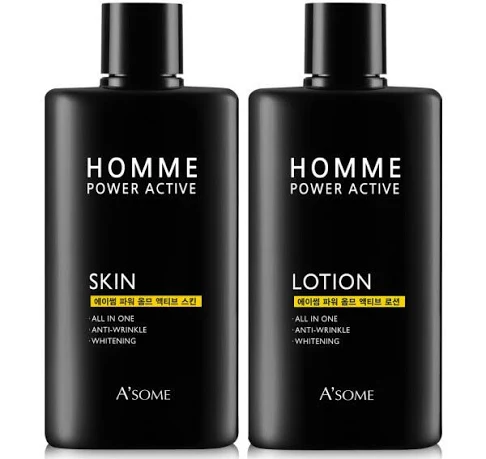

In [6]:
# ============================================================
# 이미지 로드 — 아래 3가지 방법 중 하나를 선택하세요
# ============================================================

IMAGE_FILE = "cosmetic_sample.jpg"

# --- 방법 1: Colab에서 직접 업로드 (권장) ---
# from google.colab import files
# uploaded = files.upload()                      # 파일 선택 팝업이 열립니다
# IMAGE_FILE = list(uploaded.keys())[0]

# --- 방법 2: URL에서 다운로드 ---
IMAGE_URL = "https://encrypted-tbn1.gstatic.com/shopping?q=tbn:ANd9GcTKj3vD7VJIqI8Fs4-oFpjJbh6Bq9z2k44Wi7UzXvEzwHC07jmWI1_3Ag9ngDy2D62hqMTT_V0yaVEmXInIS38ETXS73TGno_3FhRX-mt39lLmjel6W6NxHEQ"     # TODO: 이미지 URL 입력
download_image(IMAGE_URL, IMAGE_FILE)

# --- 방법 3: GCS에서 복사 ---
# !gsutil cp gs://your-bucket/chakan_vita_real.jpg {IMAGE_FILE}

# ============================================================
product_image, img_w, img_h = read_image(IMAGE_FILE)
print(f"이미지 크기: {img_w} x {img_h}")
display(product_image)

### 3-1. 전체 텍스트 및 위치 정보 추출

이미지에서 보이는 모든 텍스트를 bounding box 좌표와 함께 추출합니다.  
추가로 텍스트의 **역할**(브랜드명, 상품명, 성분, 용량 등)도 분류합니다.

In [7]:
ocr_position_prompt = """
이 상품 이미지에서 보이는 모든 텍스트를 추출하고, 각 텍스트의 위치 정보를 제공해 주세요.

각 텍스트 영역에 대해 다음 정보를 포함해 주세요:
- "text": 정확한 텍스트 내용
- "box_2d": [y1, x1, y2, x2] (0-1000 범위의 정규화된 좌표)
- "label": 텍스트의 역할 (brand_name / product_name / ingredient / volume / description / slogan / other)
- "font_size": 상대적 크기 (large / medium / small)
- "position": 이미지 내 위치 설명 (top-center / middle-left 등)

결과를 JSON 리스트로 반환해 주세요. JSON만 반환하고 다른 텍스트는 포함하지 마세요.
"""

ocr_results_raw = inference(product_image, ocr_position_prompt, temp=0.2)

try:
    ocr_data = json.loads(clean_results(ocr_results_raw))
    print(f"추출된 텍스트 영역 수: {len(ocr_data)}\n")
    print(json.dumps(ocr_data, indent=2, ensure_ascii=False))
except json.JSONDecodeError as e:
    print(f"JSON parsing failed: {e}")
    print("Raw output:")
    print(ocr_results_raw)

RefreshError: ("Failed to retrieve http://metadata.google.internal/computeMetadata/v1/instance/service-accounts/default/?recursive=true from the Google Compute Engine metadata service. Status: 404 Response:\nb''", <google.auth.transport.requests._Response object at 0x7e1854951be0>)

### 3-2. OCR 결과 시각화

추출된 텍스트 위치를 이미지 위에 bounding box로 표시하여 정확도를 확인합니다.

In [ ]:
# OCR 결과를 draw_boxes 호환 형태로 변환
box_items = [
    {"box_2d": item["box_2d"], "label": f"{item['label']}: {item['text']}"}
    for item in ocr_data
    if "box_2d" in item and "text" in item
]

annotated = draw_boxes(product_image, box_items, img_w, img_h)
display(annotated)

### 3-3. 상품 종합 정보 추출

OCR과 별도로, 이미지에서 상품의 종합 정보(브랜드, 카테고리, 특징 등)를 구조화된 JSON으로 추출합니다.  
이 정보는 Veo 3.1 프롬프트의 컨텍스트로 활용됩니다.

In [ ]:
product_analysis_prompt = """
이 상품 이미지를 분석하여 다음 정보를 JSON으로 반환해 주세요:

{
  "brand": "브랜드명",
  "product_name": "상품명",
  "category": "상품 카테고리 (예: 스킨케어, 메이크업, 헤어케어 등)",
  "key_ingredients": ["주요 성분 리스트"],
  "product_description": "상품 설명 (2-3문장)",
  "target_audience": "타겟 고객층",
  "visual_style": "패키지 디자인 스타일 (색상, 톤, 분위기)",
  "unique_selling_point": "핵심 차별점"
}

JSON만 반환하고 다른 텍스트는 포함하지 마세요.
"""

product_analysis_raw = inference(product_image, product_analysis_prompt, temp=0.2)

try:
    product_info = json.loads(clean_results(product_analysis_raw))
    print(json.dumps(product_info, indent=2, ensure_ascii=False))
except json.JSONDecodeError as e:
    print(f"JSON parsing failed: {e}")
    print(product_analysis_raw)

---
## 4. Veo 3.1 프롬프트 생성

OCR 결과와 상품 정보를 기반으로 Veo 3.1에 전달할 **영상 생성 프롬프트**를 구성합니다.  
핵심은 텍스트 왜곡 방지를 위해 **원본 텍스트를 프롬프트에 명시**하는 것입니다.

In [ ]:
def build_veo_prompt(ocr_data, product_info):
    """OCR 결과와 상품 정보를 기반으로 Veo 3.1 프롬프트를 생성합니다.

    핵심 전략: 텍스트를 '새로 렌더링'하는 것이 아니라,
    원본 이미지에 이미 존재하는 텍스트 영역을 '보존'하도록 지시합니다.
    """

    brand = product_info.get("brand", "")
    product_name = product_info.get("product_name", "")
    category = product_info.get("category", "")
    description = product_info.get("product_description", "")
    style = product_info.get("visual_style", "")
    usp = product_info.get("unique_selling_point", "")
    ingredients = product_info.get("key_ingredients", [])

    prompt = f"""Create a high-end luxury brand promotional video for the product shown in the source image.

Product Information:
- Brand: {brand}
- Product: {product_name}
- Category: {category}
- Description: {description}
- Key Ingredients: {', '.join(ingredients)}
- Unique Selling Point: {usp}

TEXT FREEZE ZONES — DO NOT MODIFY:
The source image already contains accurate text on the product label.
These text regions must be preserved pixel-perfectly throughout the entire video.
Do NOT regenerate, blur, warp, morph, or modify any text visible on the product.
The text is already correct — your job is to keep it intact, not to redraw it.

Detected text regions from OCR (ALL must remain frozen):
"""

    for item in ocr_data:
        text = item.get("text", "").strip()
        if not text:
            continue
        role = item.get("label", "other")
        position = item.get("position", "")
        font_size = item.get("font_size", "")
        box = item.get("box_2d", [])
        box_str = f", region: [{box[0]}-{box[2]}, {box[1]}-{box[3]}]" if len(box) == 4 else ""
        prompt += f'- "{text}" (role: {role}, position: {position}, size: {font_size}{box_str}) — FREEZE\n'

    print(f"텍스트 보존 지시: {len([i for i in ocr_data if i.get('text', '').strip()])}개 포함 (한글+영어 전체)")

    prompt += f"""
CAMERA & MOTION (optimized for text preservation):
- Use ONLY slow, gentle camera movements: slow zoom-in, slow zoom-out, subtle dolly forward
- AVOID rapid panning, orbiting, or any motion that crosses over text regions on the label
- Keep the product label facing the camera at all times — no extreme angle changes
- The product must remain the central hero element, always in sharp focus
- Any rotation must be extremely slow (max 15 degrees total) to prevent text distortion

CINEMATIC ATMOSPHERE:
- Three-point studio lighting: soft key light (front-left), warm fill (right), dramatic rim light (back)
- Visual tone matching the product design: {style}
- Gradient background transitioning from dark to warm tones
- Golden hour color grading with rich, warm highlights
- Volumetric light rays streaming through subtle haze behind the product

BACKGROUND EFFECTS (dynamic elements restricted to background ONLY):
- Floating micro-particles (gold shimmer) drifting slowly BEHIND the product
- Soft bokeh circles in the background, shifting gently
- Smooth light leak transitions in the background
- Subtle caustic light reflections on the surface the product sits on
- All dynamic effects must stay BEHIND or AROUND the product — never overlay on the label

NEGATIVE GUIDANCE:
- NEVER regenerate or redraw any text — preserve the original image pixels in text regions
- NO motion blur on the product label area
- NO morphing, warping, or stretching effects on the product surface
- NO camera movement fast enough to cause text smearing
- NO effects (particles, flares, light leaks) overlapping with text on the label

OVERALL MOOD:
- Luxurious, aspirational, clean — suitable for a premium {category} advertisement
- All label text (Korean and English) must be sharp, legible, and undistorted throughout the entire video
"""

    return prompt


veo_prompt = build_veo_prompt(ocr_data, product_info)
print("=" * 60)
print("Generated Veo 3.1 Prompt:")
print("=" * 60)
print(veo_prompt)

### 4-1. (선택) Gemini로 프롬프트 최적화

생성된 프롬프트를 Gemini에게 한 번 더 다듬어달라고 요청하여 품질을 높입니다.

In [ ]:
optimize_prompt = f"""
아래는 Veo 3.1 영상 생성 모델에 전달할 프롬프트입니다.
이 프롬프트를 영상 생성에 최적화된 형태로 다듬어 주세요.

규칙:
1. TEXT FREEZE ZONES 섹션은 절대 삭제하거나 약화하지 마세요. 텍스트 보존 지시는 그대로 유지해야 합니다.
2. 한글(Korean) 텍스트를 영어로 번역하지 마세요. 원본 그대로 유지해야 합니다.
3. CAMERA & MOTION 섹션의 텍스트 보존 관련 제약 조건을 유지하세요.
4. 영상 스타일 설명을 더 구체적이고 시네마틱하게 개선하세요.
5. 카메라 무브먼트는 느리고 부드러운 움직임 중심으로 유지하세요.
6. 영어로 작성하세요 (Veo 3.1은 영어 프롬프트가 가장 효과적).
7. 프롬프트만 반환하고 다른 설명은 포함하지 마세요.

---
{veo_prompt}
"""

optimized_prompt = client.models.generate_content(
    model=GEMINI_MODEL_ID,
    contents=[optimize_prompt],
    config=types.GenerateContentConfig(temperature=0.7),
).text

print("=" * 60)
print("Optimized Veo 3.1 Prompt:")
print("=" * 60)
print(optimized_prompt)

---
## 5. Veo 3.1 브랜드 홍보 영상 생성

원본 상품 이미지와 OCR 기반 프롬프트를 결합하여 Veo 3.1로 브랜드 홍보 영상을 생성합니다.

> **참고:** Veo 3.1 영상 생성은 비동기 작업입니다. 완료까지 수 분이 소요될 수 있습니다.

### 5-1. 방법 A — 이미지 기반 영상 생성 (Image-to-Video)

원본 상품 이미지를 첫 프레임으로 사용하여 영상을 생성합니다.  
이미지의 구도와 텍스트 배치가 유지되므로 텍스트 왜곡이 최소화됩니다.

In [ ]:
# 원본 이미지를 Veo 3.1 입력용으로 로드
veo_image = types.Image.from_file(location=IMAGE_FILE)

# Image-to-Video 생성 (원본 이미지 + OCR 기반 프롬프트)
print("Veo 3.1 영상 생성을 시작합니다...")
print(f"모델: {VEO_MODEL_ID}")
print(f"출력 경로: {OUTPUT_GCS_URI}")

operation = client.models.generate_videos(
    model=VEO_MODEL_ID,
    image=veo_image,
    prompt=optimized_prompt,
    config=types.GenerateVideosConfig(
        number_of_videos=1,
        output_gcs_uri=OUTPUT_GCS_URI,
        aspect_ratio="9:16",       # 세로 영상 (모바일 홍보용)
        resolution="720p",
        person_generation="dont_allow",
        negative_prompt="blurry text, distorted letters, misspelled words, warped Korean text, distorted CJK characters, modified label text, regenerated text, motion blur on text, morphed product surface, low quality, watermark",
        generate_audio=False,
    ),
)

# 완료까지 대기
print("\n영상 생성 중...")
while not operation.done:
    time.sleep(20)
    operation = client.operations.get(operation=operation)
    print("  ... 생성 진행 중")

print("\n영상 생성 완료!")

# 결과 확인
for i, generated_video in enumerate(operation.result.generated_videos):
    video = generated_video.video
    print(f"\n영상 {i+1}:")
    print(f"  URI: {video.uri}")

In [ ]:
# 생성된 영상 다운로드 및 재생
video = operation.result.generated_videos[0].video
gcs_uri = video.uri
print(f"영상 GCS 경로: {gcs_uri}")

!gsutil cp {gcs_uri} brand_promo_image_to_video.mp4
print("영상 저장 완료: brand_promo_image_to_video.mp4")

Video("brand_promo_image_to_video.mp4", embed=True, width=400)

### 5-2. 방법 B — 레퍼런스 이미지 기반 생성 (Reference Image)

원본 이미지를 **ASSET 레퍼런스**로 사용하여 영상을 생성합니다.  
Image-to-Video와 달리 첫 프레임에 구속되지 않아 더 다양한 카메라 워크가 가능합니다.

In [ ]:
print("Veo 3.1 레퍼런스 이미지 기반 영상 생성을 시작합니다...")

operation_ref = client.models.generate_videos(
    model=VEO_MODEL_ID,
    prompt=optimized_prompt,
    config=types.GenerateVideosConfig(
        number_of_videos=1,
        output_gcs_uri=OUTPUT_GCS_URI,
        aspect_ratio="16:9",       # 가로 영상 (유튜브/웹 홍보용)
        resolution="720p",
        person_generation="dont_allow",
        negative_prompt="blurry text, distorted letters, misspelled words, warped Korean text, distorted CJK characters, modified label text, regenerated text, motion blur on text, morphed product surface, low quality, watermark",
        generate_audio=False,
        reference_images=[
            types.VideoGenerationReferenceImage(
                image=types.Image.from_file(location=IMAGE_FILE),
                reference_type=types.VideoGenerationReferenceType.ASSET,
            ),
        ],
    ),
)

# 완료까지 대기
print("\n영상 생성 중...")
while not operation_ref.done:
    time.sleep(20)
    operation_ref = client.operations.get(operation=operation_ref)
    print("  ... 생성 진행 중")

print("\n영상 생성 완료!")

for i, generated_video in enumerate(operation_ref.result.generated_videos):
    video = generated_video.video
    print(f"\n영상 {i+1}:")
    print(f"  URI: {video.uri}")

In [ ]:
# 레퍼런스 이미지 기반 영상 다운로드 및 재생
video_ref = operation_ref.result.generated_videos[0].video
gcs_uri_ref = video_ref.uri
print(f"영상 GCS 경로: {gcs_uri_ref}")

!gsutil cp {gcs_uri_ref} brand_promo_reference.mp4
print("영상 저장 완료: brand_promo_reference.mp4")

Video("brand_promo_reference.mp4", embed=True, width=600)

### 5-3. 결과 비교

두 방법으로 생성된 영상의 특징을 비교합니다.

| 항목 | 방법 A (Image-to-Video) | 방법 B (Reference Image) |
|------|------------------------|-------------------------|
| 첫 프레임 | 원본 이미지 고정 | 자유롭게 생성 |
| 텍스트 보존 | 높음 (첫 프레임에 고정) | 중간 (프롬프트 의존) |
| 카메라 워크 | 제한적 (줌, 패닝) | 다양 (오빗, 돌리 등) |
| 추천 용도 | 텍스트 정확성 중시 | 시네마틱 연출 중시 |
| 비율 | 9:16 (모바일/숏폼) | 16:9 (유튜브/웹) |

### 참고: 한글 텍스트 보존 전략 — Text Freeze Zone

Veo 3.1을 포함한 비디오 생성 모델은 텍스트를 "의미"가 아닌 "시각적 패턴"으로 처리하므로, 텍스트를 새로 렌더링하면 왜곡이 발생합니다. 특히 한글(CJK) 문자는 학습 데이터 부족으로 더 심하게 깨집니다.

#### 이 노트북의 접근법: "렌더링"이 아닌 "보존"

| 전략 | 설명 |
|------|------|
| **Text Freeze Zone** | OCR로 추출한 텍스트 위치(box_2d)를 프롬프트에 명시하고, 해당 영역의 픽셀을 변형하지 않도록 지시합니다. |
| **Image-to-Video 모드** | 원본 이미지를 첫 프레임으로 고정하므로, 이미지에 있는 한글 텍스트가 정확한 상태에서 출발합니다. |
| **카메라 워크 제한** | 텍스트 영역을 지나는 빠른 움직임을 피하고, 느린 줌/돌리 위주로 텍스트 왜곡을 최소화합니다. |
| **배경 효과 분리** | 파티클, 보케, 라이트 리크 등 동적 효과를 배경에만 적용하여 라벨 영역을 보호합니다. |

#### 한글 텍스트 보존 팁

1. **Image-to-Video 방식(방법 A)을 우선 사용하세요** — 원본 이미지의 텍스트를 첫 프레임으로 고정하므로 보존율이 가장 높습니다.
2. **카메라 움직임이 적을수록 텍스트 보존이 좋습니다** — 격렬한 오빗/패닝보다 느린 줌인이 효과적입니다.
3. **OCR 데이터의 정확성이 중요합니다** — Gemini OCR이 텍스트 위치를 정확히 추출해야 Freeze Zone이 효과적으로 작동합니다.
4. **완벽한 보존은 보장되지 않습니다** — 비디오 생성 모델의 근본적 한계로, 프레임이 진행될수록 미세한 변형이 발생할 수 있습니다. 특히 8초 영상의 후반부에서 텍스트 품질이 저하될 수 있습니다.

In [ ]:
# image_path = "your_product_image.jpg"  # TODO: 본인의 이미지 경로로 변경
# my_image, my_w, my_h = read_image(image_path)
# display(my_image)
#
# # Step 1: OCR 텍스트 + 위치 추출
# print("=== Step 1: OCR 텍스트 추출 ===")
# my_ocr_raw = inference(my_image, ocr_position_prompt, temp=0.2)
# my_ocr_data = json.loads(clean_results(my_ocr_raw))
# print(json.dumps(my_ocr_data, indent=2, ensure_ascii=False))
#
# # OCR 시각화
# my_box_items = [
#     {"box_2d": item["box_2d"], "label": f"{item['label']}: {item['text']}"}
#     for item in my_ocr_data if "box_2d" in item and "text" in item
# ]
# display(draw_boxes(my_image, my_box_items, my_w, my_h))
#
# # Step 2: 상품 정보 추출
# print("\n=== Step 2: 상품 정보 분석 ===")
# my_product_raw = inference(my_image, product_analysis_prompt, temp=0.2)
# my_product_info = json.loads(clean_results(my_product_raw))
# print(json.dumps(my_product_info, indent=2, ensure_ascii=False))
#
# # Step 3: Veo 프롬프트 생성
# print("\n=== Step 3: Veo 3.1 프롬프트 ===")
# my_veo_prompt = build_veo_prompt(my_ocr_data, my_product_info)
# print(my_veo_prompt)
#
# # Step 4: 영상 생성
# print("\n=== Step 4: 영상 생성 ===")
# my_veo_image = types.Image.from_file(location=image_path)
# my_operation = client.models.generate_videos(
#     model=VEO_MODEL_ID,
#     image=my_veo_image,
#     prompt=my_veo_prompt,
#     config=types.GenerateVideosConfig(
#         number_of_videos=1,
#         output_gcs_uri=OUTPUT_GCS_URI,
#         aspect_ratio="9:16",
#         resolution="720p",
#         person_generation="dont_allow",
#         negative_prompt="blurry text, distorted letters, misspelled words, warped Korean text, distorted CJK characters, modified label text, regenerated text, motion blur on text, morphed product surface, low quality, watermark",
#         generate_audio=False,
#     ),
# )
#
# while not my_operation.done:
#     time.sleep(20)
#     my_operation = client.operations.get(operation=my_operation)
#     print("  ... 생성 진행 중")
#
# my_video = my_operation.result.generated_videos[0].video
# my_gcs_uri = my_video.uri
# !gsutil cp {my_gcs_uri} my_brand_promo.mp4
# print("영상 저장 완료: my_brand_promo.mp4")
# Video("my_brand_promo.mp4", embed=True, width=400)